In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (precision_recall_curve,
                             average_precision_score,
                             f1_score, precision_score,
                             recall_score, confusion_matrix,
                             roc_auc_score)



In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.4f' % x)


lr        = joblib.load('../models/logistic_regression.pkl')
rf        = joblib.load('../models/random_forest.pkl')
xgb_model = joblib.load('../models/xgboost.pkl')

X_validate        = joblib.load('../models/X_validate.pkl')
X_test            = joblib.load('../models/X_test.pkl')
y_validate        = joblib.load('../models/y_validate.pkl')
y_test            = joblib.load('../models/y_test.pkl')
X_validate_scaled = joblib.load('../models/X_validate_scaled.pkl')
X_test_scaled     = joblib.load('../models/X_test_scaled.pkl')



print("Models loaded ")
print("Validate and test sets loaded ")
print(f"Validate: {X_validate.shape}")
print(f"Test:     {X_test.shape}")
print(f"Validate fraud rate: {y_validate.mean()*100:.3f}%")
print(f"Test fraud rate:     {y_test.mean()*100:.3f}%")


Models loaded 
Validate and test sets loaded 
Validate: (42721, 30)
Test:     (42722, 30)
Validate fraud rate: 0.131%
Test fraud rate:     0.122%


In [4]:
# get fraud probability scores from all three models
# predict_proba returns [prob_legitimate, prob_fraud]
# [:, 1] gets fraud probability only

# on validate set
lr_probs_val  = lr.predict_proba(X_validate_scaled)[:, 1]
rf_probs_val  = rf.predict_proba(X_validate)[:, 1]
xgb_probs_val = xgb_model.predict_proba(X_validate)[:, 1]

# on test set
lr_probs_test  = lr.predict_proba(X_test_scaled)[:, 1]
rf_probs_test  = rf.predict_proba(X_test)[:, 1]
xgb_probs_test = xgb_model.predict_proba(X_test)[:, 1]

print("Predictions generated ")
print(f"\nScore ranges on validate set:")
print(f"LR  → min: {lr_probs_val.min():.4f} | max: {lr_probs_val.max():.4f} | mean: {lr_probs_val.mean():.4f}")
print(f"RF  → min: {rf_probs_val.min():.4f} | max: {rf_probs_val.max():.4f} | mean: {rf_probs_val.mean():.4f}")
print(f"XGB → min: {xgb_probs_val.min():.4f} | max: {xgb_probs_val.max():.4f} | mean: {xgb_probs_val.mean():.4f}")

Predictions generated 

Score ranges on validate set:
LR  → min: 0.0000 | max: 1.0000 | mean: 0.0948
RF  → min: 0.0001 | max: 0.9995 | mean: 0.0149
XGB → min: 0.0000 | max: 1.0000 | mean: 0.0016


In [ ]:


def calculate_ks(y_true, y_prob):
    """
    Calculate KS statistic
    KS = max difference between cumulative fraud and legitimate distributions
    """
    # create dataframe of scores and labels
    df = pd.DataFrame({'score': y_prob, 'label': y_true})
    df = df.sort_values('score', ascending=False).reset_index(drop=True)
    
    # cumulative % of fraud and legitimate captured
    df['cum_fraud'] = (df['label'] == 1).cumsum() / (df['label'] == 1).sum()
    df['cum_legit'] = (df['label'] == 0).cumsum() / (df['label'] == 0).sum()
    
    # KS = max difference
    df['ks'] = abs(df['cum_fraud'] - df['cum_legit'])
    ks_stat = df['ks'].max()
    ks_threshold = df.loc[df['ks'].idxmax(), 'score']
    
    return ks_stat, ks_threshold, df

# calculate KS for all models on validate set
lr_ks,  lr_ks_threshold,  lr_ks_df  = calculate_ks(y_validate, lr_probs_val)
rf_ks,  rf_ks_threshold,  rf_ks_df  = calculate_ks(y_validate, rf_probs_val)
xgb_ks, xgb_ks_threshold, xgb_ks_df = calculate_ks(y_validate, xgb_probs_val)

print("KS Statistics (Validate Set):")
print(f"Logistic Regression: KS = {lr_ks:.4f} | threshold = {lr_ks_threshold:.4f}")
print(f"Random Forest:       KS = {rf_ks:.4f} | threshold = {rf_ks_threshold:.4f}")
print(f"XGBoost:             KS = {xgb_ks:.4f} | threshold = {xgb_ks_threshold:.4f}")

KS Statistics (Validate Set):
Logistic Regression: KS = 0.9223 | threshold = 0.8808
Random Forest:       KS = 0.9028 | threshold = 0.0945
XGBoost:             KS = 0.9241 | threshold = 0.0114


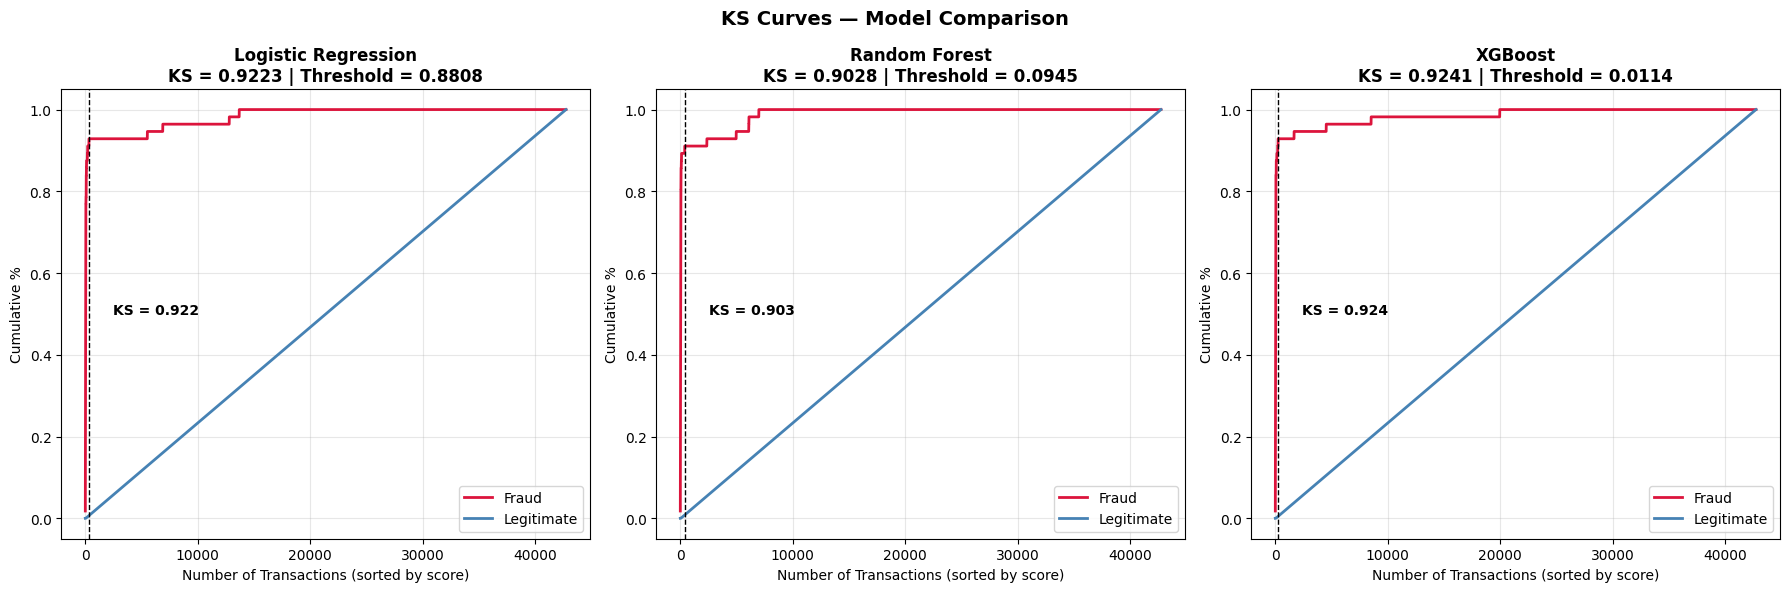

In [6]:
# plot KS curves for all three models
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

models = {
    'Logistic Regression': (lr_ks_df, lr_ks, lr_ks_threshold),
    'Random Forest':       (rf_ks_df, rf_ks, rf_ks_threshold),
    'XGBoost':             (xgb_ks_df, xgb_ks, xgb_ks_threshold)
}

for i, (name, (df, ks, threshold)) in enumerate(models.items()):
    axes[i].plot(df.index, df['cum_fraud'], 
                 color='crimson', linewidth=2, label='Fraud')
    axes[i].plot(df.index, df['cum_legit'], 
                 color='steelblue', linewidth=2, label='Legitimate')
    
    # mark KS point
    ks_idx = df['ks'].idxmax()
    axes[i].axvline(x=ks_idx, color='black', 
                    linestyle='--', linewidth=1)
    axes[i].annotate(f'KS = {ks:.3f}', 
                     xy=(ks_idx, df.loc[ks_idx, 'cum_fraud']),
                     xytext=(ks_idx + len(df)*0.05, 0.5),
                     fontsize=10, fontweight='bold')
    
    axes[i].set_title(f'{name}\nKS = {ks:.4f} | Threshold = {threshold:.4f}',
                      fontweight='bold')
    axes[i].set_xlabel('Number of Transactions (sorted by score)')
    axes[i].set_ylabel('Cumulative %')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.suptitle('KS Curves — Model Comparison', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

In [11]:
lr_auprc = average_precision_score(y_validate, lr_probs_val)
rf_auprc = average_precision_score(y_validate, rf_probs_val)
xgb_auprc = average_precision_score(y_validate, xgb_probs_val)



print("AUPRC Scores (Validate Set):")
print(f"Logistic Regression: {lr_auprc:.4f}")
print(f"Random Forest:       {rf_auprc:.4f}")
print(f"XGBoost:             {xgb_auprc:.4f}")


baseline = y_validate.mean()
print(f"\nBaseline (random): {baseline:.4f}")
print(f"\nXGBoost lift over baseline: {xgb_auprc/baseline:.1f}x")

AUPRC Scores (Validate Set):
Logistic Regression: 0.8324
Random Forest:       0.8660
XGBoost:             0.8690

Baseline (random): 0.0013

XGBoost lift over baseline: 663.0x


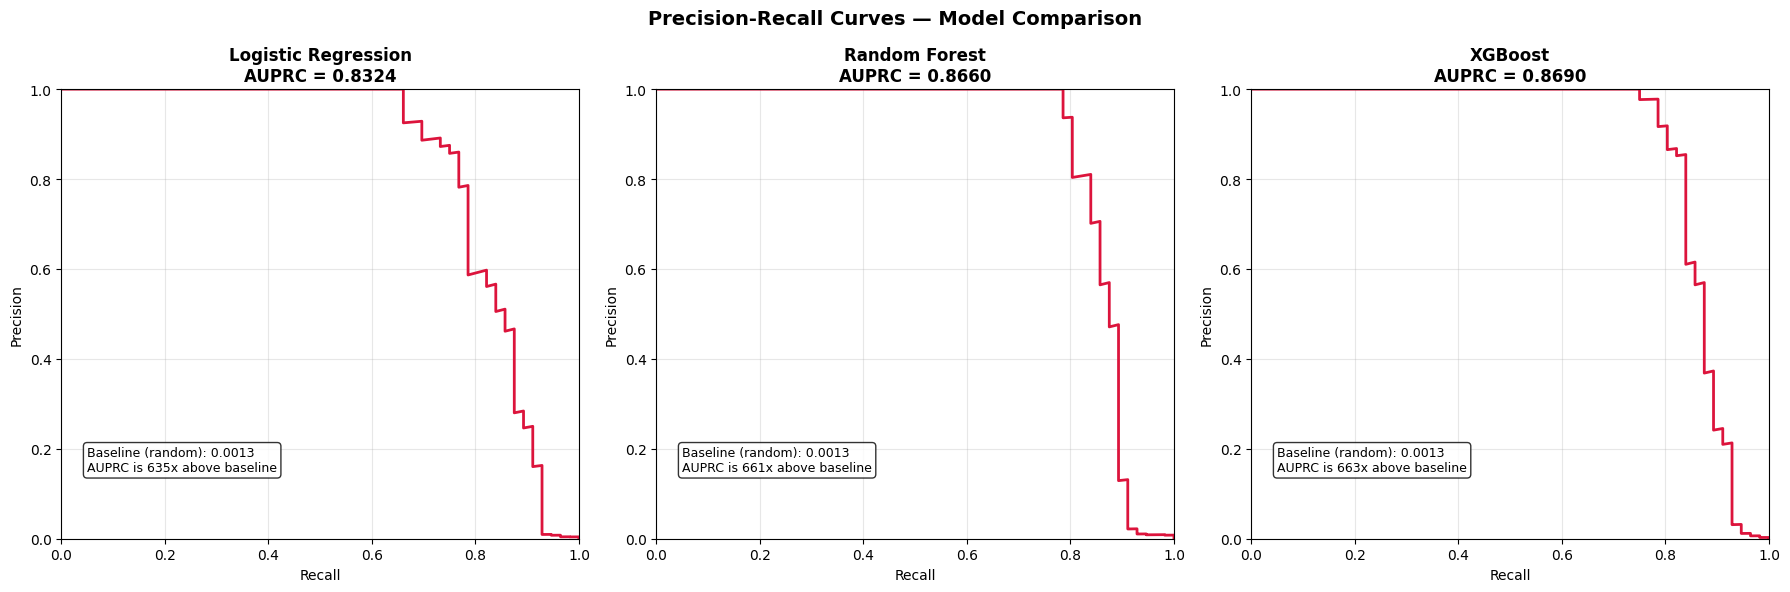

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

models = {
    'Logistic Regression': (lr_probs_val,  lr_auprc),
    'Random Forest':       (rf_probs_val,  rf_auprc),
    'XGBoost':             (xgb_probs_val, xgb_auprc)
}

for i, (name, (probs, auprc)) in enumerate(models.items()):
    precision, recall, thresholds = precision_recall_curve(y_validate, probs)
    
    axes[i].plot(recall, precision, color='crimson', linewidth=2)
    
    # baseline too small to see as line — add as text annotation instead
    axes[i].text(0.05, 0.15, 
                 f'Baseline (random): {y_validate.mean():.4f}\nAUPRC is {auprc/y_validate.mean():.0f}x above baseline',
                 transform=axes[i].transAxes,
                 fontsize=9, color='black',
                 bbox=dict(boxstyle='round', facecolor='white', 
                           edgecolor='black', alpha=0.8))
    
    axes[i].set_title(f'{name}\nAUPRC = {auprc:.4f}', fontweight='bold')
    axes[i].set_xlabel('Recall')
    axes[i].set_ylabel('Precision')
    axes[i].grid(True, alpha=0.3)
    axes[i].set_xlim([0, 1])
    axes[i].set_ylim([0, 1])

plt.suptitle('Precision-Recall Curves — Model Comparison', 
             fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

In [15]:


def find_best_f1_threshold(y_true, y_prob):
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    
    # calculate F1 at each threshold
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
    
    best_idx       = f1_scores.argmax()
    best_f1        = f1_scores[best_idx]
    best_threshold = thresholds[best_idx] if best_idx < len(thresholds) else thresholds[-1]
    best_precision = precision[best_idx]
    best_recall    = recall[best_idx]
    
    return best_f1, best_threshold, best_precision, best_recall

print("Best F1 Scores (Validate Set):")


for name, probs in [('Logistic Regression', lr_probs_val),
                     ('Random Forest',       rf_probs_val),
                     ('XGBoost',             xgb_probs_val)]:
    f1, threshold, prec, rec = find_best_f1_threshold(y_validate, probs)
    print(f"{name}:")
    print(f"  F1={f1:.4f} | Threshold={threshold:.4f} | "
          f"Precision={prec:.4f} | Recall={rec:.4f}")
    print()

Best F1 Scores (Validate Set):
Logistic Regression:
  F1=0.8113 | Threshold=1.0000 | Precision=0.8600 | Recall=0.7679

Random Forest:
  F1=0.8800 | Threshold=0.4909 | Precision=1.0000 | Recall=0.7857

XGBoost:
  F1=0.8713 | Threshold=0.9041 | Precision=0.9778 | Recall=0.7857



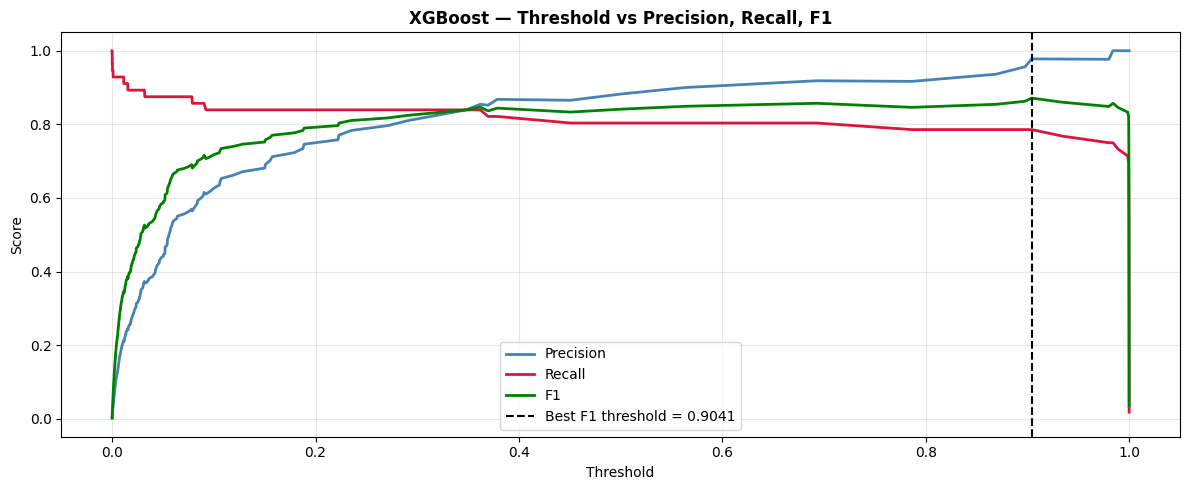

Best F1 threshold: 0.9041
At this threshold:
  Precision: 0.9778
  Recall:    0.7857
  F1:        0.8713


In [16]:
# threshold vs precision and recall — XGBoost only (champion model)
precision, recall, thresholds = precision_recall_curve(y_validate, xgb_probs_val)

# align lengths — precision/recall have one more element than thresholds
precision  = precision[:-1]
recall     = recall[:-1]

# calculate F1 at each threshold
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
best_idx  = f1_scores.argmax()

plt.figure(figsize=(12, 5))

plt.plot(thresholds, precision, color='steelblue', linewidth=2, label='Precision')
plt.plot(thresholds, recall,    color='crimson',   linewidth=2, label='Recall')
plt.plot(thresholds, f1_scores, color='green',     linewidth=2, label='F1')

# mark best F1 threshold
plt.axvline(x=thresholds[best_idx], color='black', 
            linestyle='--', linewidth=1.5,
            label=f'Best F1 threshold = {thresholds[best_idx]:.4f}')

plt.title('XGBoost — Threshold vs Precision, Recall, F1', fontweight='bold')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Best F1 threshold: {thresholds[best_idx]:.4f}")
print(f"At this threshold:")
print(f"  Precision: {precision[best_idx]:.4f}")
print(f"  Recall:    {recall[best_idx]:.4f}")
print(f"  F1:        {f1_scores[best_idx]:.4f}")

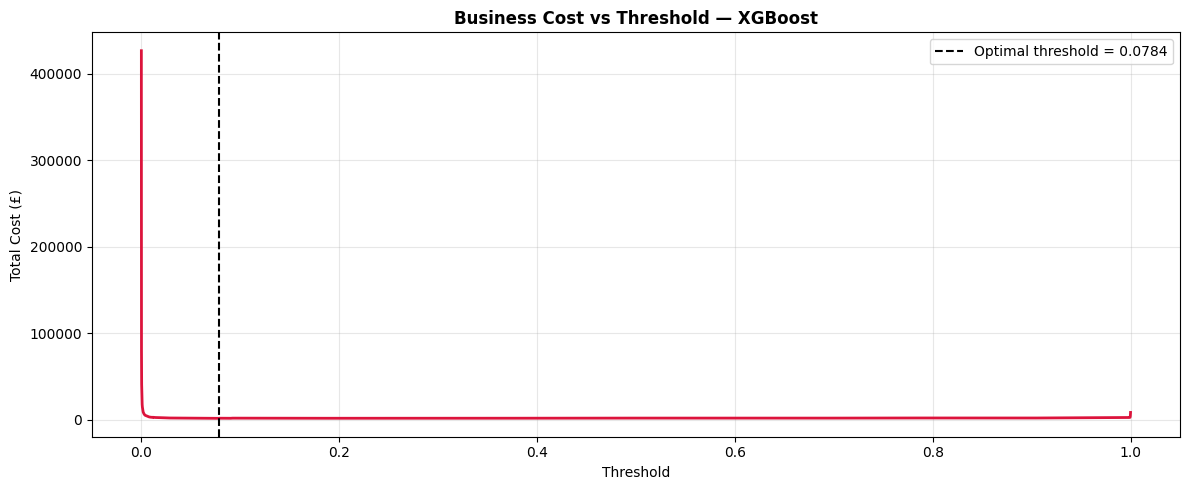

Optimal business threshold: 0.0784
At this threshold:
  Precision: 0.5698
  Recall:    0.8750
  F1:        0.6901
  Estimated total cost: £1,420

Compare with F1 optimal threshold (0.9041):
  Estimated total cost: £1,810


In [17]:
# business cost threshold optimisation
# in banking missing fraud is more expensive than false alarms
# we assign costs to each type of error

# cost assumptions (realistic UK banking)
cost_false_negative = 150  # average fraud amount missed (£)
cost_false_positive = 10   # cost of investigating false alarm (£)
                            # customer service call + friction

precision, recall, thresholds = precision_recall_curve(y_validate, xgb_probs_val)
precision = precision[:-1]
recall    = recall[:-1]

# total fraud in validate set
total_fraud = y_validate.sum()
total_legit = (y_validate == 0).sum()

costs = []
for i, threshold in enumerate(thresholds):
    # at this threshold:
    tp = recall[i] * total_fraud          # fraud caught
    fn = (1 - recall[i]) * total_fraud    # fraud missed
    fp = (1 - precision[i]) * (tp / precision[i]) if precision[i] > 0 else total_legit
    
    total_cost = (fn * cost_false_negative) + (fp * cost_false_positive)
    costs.append(total_cost)

costs = np.array(costs)
best_cost_idx = costs.argmin()
best_cost_threshold = thresholds[best_cost_idx]

plt.figure(figsize=(12, 5))
plt.plot(thresholds, costs, color='crimson', linewidth=2)
plt.axvline(x=best_cost_threshold, color='black', linestyle='--',
            label=f'Optimal threshold = {best_cost_threshold:.4f}')
plt.title('Business Cost vs Threshold — XGBoost', fontweight='bold')
plt.xlabel('Threshold')
plt.ylabel('Total Cost (£)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Optimal business threshold: {best_cost_threshold:.4f}")
print(f"At this threshold:")
print(f"  Precision: {precision[best_cost_idx]:.4f}")
print(f"  Recall:    {recall[best_cost_idx]:.4f}")
print(f"  F1:        {2*(precision[best_cost_idx]*recall[best_cost_idx])/(precision[best_cost_idx]+recall[best_cost_idx]):.4f}")
print(f"  Estimated total cost: £{costs[best_cost_idx]:,.0f}")
print(f"\nCompare with F1 optimal threshold ({0.9041:.4f}):")
f1_idx = np.argmin(np.abs(thresholds - 0.9041))
print(f"  Estimated total cost: £{costs[f1_idx]:,.0f}")